# **Analisi sull'intensità dei venti estremi nel Nordatlantico (1851-2025)**

L'obiettivo di questo esercizio è quello di:

individuare i valori estremi della velocità del Vento associati a tempeste tropicali generate nel mar dei Caraibi, dal 1851 al 2025, attraverso il modello Block Maxima e Peaks over threshold.

Ed Infine stimare i periodi di ritorno di queste misurazioni estreme.
Si utilizzeranno per questi scopi le funzioni della libreria apposita, Pyextreme.

I dati sono stati raccolti e compilati dalla collaborazione tra la National Oceanic and Atmospheric Administration e la National Centers for Environmental Information. Il dataset è composto da 110687 record e 10 variabili: SID (numero identificativo), NUMBER (ordine di formazione nell'arco dell'anno), BASIN (macroarea d'appartenenza) SUBBASIN (sottosettore), NATURE (classificazione), LAT e LONG (coordinate del ciclone), WHO_WIND (velocità del vento in nodi), WHO_PRES (pressione minima espressa in ettopascal, hPa) e ISO_TIME (data in formato ISO convertita in Datetime per questo progetto). Il dataset è disponibile su questo link. [texto del vínculo](https://geo.btaa.org/catalog/3e5fab8f-6541-45b9-a89d-b1fd7f445d02?)  

In [ ]:
# Installiamo la libreria pyextreme e importiamo la classe EVA per l'esecuzione del metodo Block Maxima,  e il metodo get_return_periods per stimare i periodi di ritorno.

!pip install pyextremes

import pandas as pd
from pyextremes import EVA
from pyextremes import get_return_periods
from dateutil.parser import parse
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.1 MB/s eta 0:00:00


In [ ]:
# Creazione e pulizia del dataset.

from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Cyclones_clean.csv"
df = pd.read_csv(path)
df.dropna()

print(df.head())
print(df.shape)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
             SID  NUMBER           BASIN        SUBBASIN    NATURE   LAT  \
0  1852232N21293       4  North Atlantic  Gulf of Mexico  Tropical  30.1   
1  1853242N12336       6  North Atlantic  North Atlantic  Tropical  19.3   
2  1854246N25300       8  North Atlantic  North Atlantic  Tropical  28.2   
3  1854246N25300       8  North Atlantic  North Atlantic  Tropical  31.6   
4  1854246N25300       8  North Atlantic  North Atlantic  Tropical  31.7   

    LON  WMO_WIND  WMO_PRES        DATA  
0 -88.6     100.0     961.0  1852-08-26  
1 -56.2     130.0     924.0  1853-09-03  
2 -78.6     110.0     938.0  1854-09-07  
3 -81.0     100.0     950.0  1854-09-08  
4 -81.0     100.0     950.0  1854-09-08  
(20898, 10)


In [ ]:
print(type(df))
df['DATA'] = pd.to_datetime(
    df['DATA']
)



<class 'pandas.core.frame.DataFrame'>


In [ ]:

# Creazione della serie temporale con la variabile WHO_WIND, indicante l'intensità dei venti associate alle perturbazioni.

dati = (
    df.groupby("DATA")["WMO_WIND"]
      .max()

)

print(dati)



DATA
1852-08-26    100.0
1853-09-03    130.0
1854-09-07    110.0
1854-09-08    100.0
1855-08-27     50.0
              ...  
2024-11-14     35.0
2024-11-15     45.0
2024-11-16     45.0
2024-11-17     35.0
2024-11-18     25.0
Name: WMO_WIND, Length: 5102, dtype: float64


/usr/local/lib/python3.12/dist-packages/pyextremes/extremes/block_maxima.py:138: NoDataBlockWarning: 10 blocks contained no data
  warnings.warn(


(<Figure size 768x480 with 1 Axes>, <Axes: xlabel='DATA', ylabel='WMO_WIND'>)

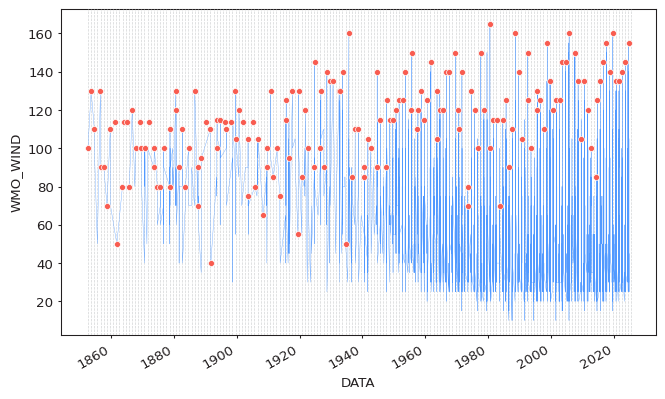

In [ ]:
# Associamo la classe EVA contenente i tools per l'analisi dei nostri dati alla serie (dati) ricavata dal nostro dataframe.
# Creiamo il nostro modello Block Maxima utilizzando la funzione get_extreme.
# Suddividiamo la nostra serie in blocchi di un anno ciascuno.
# Ed elaboriamo i plot via plot_extremes. Sono chiaramente visibili i valori estremi.

model = EVA(dati)

model.get_extremes(method="BM", block_size=pd.to_timedelta("365.2425D"), errors="coerce")

model.plot_extremes()

In [ ]:
print(len(model.extremes))
model.extremes

173


,WMO_WIND
DATA,
1852-08-26,100.0
1853-09-03,130.0
1854-09-07,110.0
1856-08-10,130.0
1856-08-28,90.0
...,...
2020-11-16,135.0
2021-09-26,135.0
2022-09-28,140.0


In [ ]:
# La seguente tabella mostra i valori estremi in ordine decrescente e reinforza ciò che abbiamo potuto apprezzare nel grafico; questa volta indicandoci la data esatta.

model.extremes.sort_values(ascending=False)

,WMO_WIND
DATA,
1980-08-07,165.0
2019-09-01,160.0
1988-09-14,160.0
1935-09-03,160.0
2005-10-19,160.0
...,...
1908-05-29,65.0
1919-07-04,55.0
1861-11-03,50.0


In [ ]:
# Si stimano i valori dei parametri in base alla distribuzione dei nostri outliers.

model.fit_model()

In [ ]:

# Calcoliamo i valori di ritorno fra 10, 20, 50, 100 anni
# L'intervallo di confidenza, alpha, è del 95%.


summary = model.get_summary(
    return_period=[10, 20, 50, 100],
    alpha=0.95, n_samples=1000,)

print(summary)

               return value    lower ci  upper ci
return period                                    
10.0             144.715714  142.607881     165.0
20.0             151.260665  149.166004     165.0
50.0             157.381757  155.016081     165.0
100.0            160.694298  157.759081     165.0


In [ ]:
# Il parametro c (ξ) di valore 0.396 ci informa che la distribuzione dei valori estremi dei nostri dati rientra nel campo della distribuzione di di Fréchet.

model.distribution

               pyextremes distribution               
-----------------------------------------------------
name: genextreme                                     
free parameters: c, loc, scale                       
fixed parameters: all parameters are free            
fitted parameters: c=0.396, loc=106.751, scale=25.498
-----------------------------------------------------

(<Figure size 768x768 with 4 Axes>,
 (<Axes: title={'center': 'Return value plot'}, xlabel='Return period', ylabel='WMO_WIND'>,
  <Axes: title={'center': 'Probability density plot'}, xlabel='WMO_WIND', ylabel='Probability density'>,
  <Axes: title={'center': 'Q-Q plot'}, xlabel='Theoretical', ylabel='Observed'>,
  <Axes: title={'center': 'P-P plot'}, xlabel='Theoretical', ylabel='Observed'>))

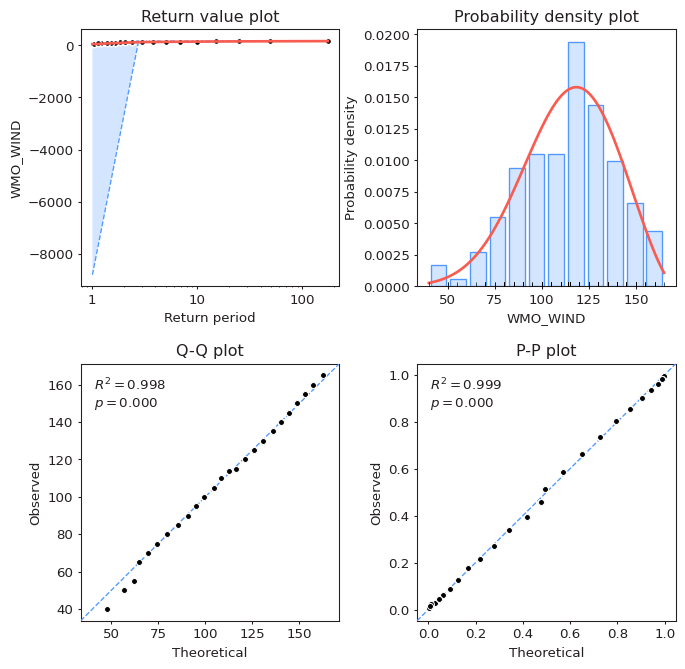

In [ ]:
# Il Return value plot mostra l'instabilità del modello con valori negativi irrealistici e una stima svhiacciata verso lo 0.
# La Probability density plot confronta la funzione di probabilità stimata con la reale distribuzione del data frame. Il risultato è una distribuzione pseudo normale con coda
# leggermente pesante a sinistra verso i valori minimi a scapito degli estremi.
# Il Q-Q plot illustra un quasi perfetto fit tra i quantili della distribuzione della funzione di Fréchet e quelli dei picchi massimi considerati, R2 euivalente al 98%
# Ugualmente nel P-P plot, la funzione cumulativa degli estremi si sovrappone molto bene con la funzione cumulativa stimata, 99%, valori cosi alti si spiegano con il minor numero divalori estremi
# presi in considerazione dal modello. Come si evince dal Return value plot questi indici non garantiscono una stima ottimale del periodi di ritorno.

model.plot_diagnostic(alpha=0.95)

In [ ]:
# Tramite get_return_periods ricaviamo i periodi di ritorno e la probabilità di superamento dei picchi massimi.

return_periods = get_return_periods(
    ts=dati,
    extremes=model.extremes,
    extremes_method="BM",
    extremes_type="high",
    block_size="365.2425D",
    return_period_size="365.2425D",
    plotting_position="weibull",)

In [ ]:
# Secondo il modello c'è una probabilità dello 0.57% che l'evento più estremo, 165 kn, si ripeta in un determinato anno. Mentre nell'orizzonte dei 50 anni la probabilità che l'intensità dei venti raggiunga
# i 160 nodi è del 2%.

return_periods.sort_values("return period", ascending=False).head()

,WMO_WIND,exceedance probability,return period
DATA,,,
1980-08-07,165.0,0.005747,174.000000
2019-09-01,160.0,0.020115,49.714286
1988-09-14,160.0,0.020115,49.714286
1935-09-03,160.0,0.020115,49.714286
2005-10-19,160.0,0.020115,49.714286


In [ ]:
 # Il seguente codice compara i valori estremi della velocità del vento giornaliera tra due periodi differenti

periodo1 = dati[dati.index.year < 1950]
periodo2 = dati[dati.index.year >= 1950]

In [ ]:
annual_max_1 = periodo1.resample("Y").max()
annual_max_2 = periodo2.resample("Y").max()

annual_max_1 = annual_max_1.dropna()
annual_max_2 = annual_max_2.dropna()

len(annual_max_1), len(annual_max_2)

/tmp/ipython-input-1241410305.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_max_1 = periodo1.resample("Y").max()
/tmp/ipython-input-1241410305.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_max_2 = periodo2.resample("Y").max()


(84, 75)

In [ ]:
from scipy.stats import genextreme

gev1 = genextreme.fit(annual_max_1)
gev2 = genextreme.fit(annual_max_2)

In [ ]:
# Il risultato conferma che nel periodo più recente si osservano più eventi estremi.
# Ciò è da probabilmente attribuire alla disponibilità di strumentazioni più efficenti ed ad una maggiore diligenza nella loro registrazione

import numpy as np

def return_level_gev(params, T):
    c, loc, scale = params
    return genextreme.ppf(1 - 1/T, c, loc=loc, scale=scale)

z100_1 = return_level_gev(gev1, 100)
z100_2 = return_level_gev(gev2, 100)

print(z100_1, z100_2)

159.99999999279396 163.18398412500483


(<Axes: ylabel='Shape, $\\xi$'>,
 <Axes: xlabel='Threshold', ylabel='Modified scale, $\\sigma^*$'>)

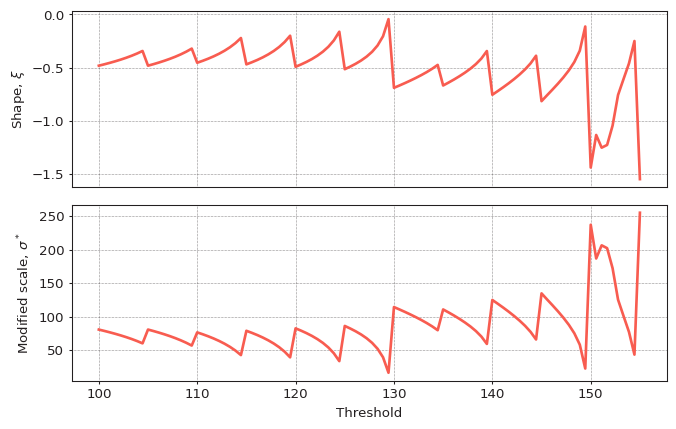

In [ ]:
# I grafici per la selezione della threshold indicano un range accettabile nella selezione della soglia tra 110 e 145 kn.
# L'indice shape, ξ, non cambia mai segno è diviene instabile oltre la soglia dei 145.

from pyextremes import plot_parameter_stability

plot_parameter_stability(dati)


<Axes: xlabel='Threshold', ylabel='Return value'>

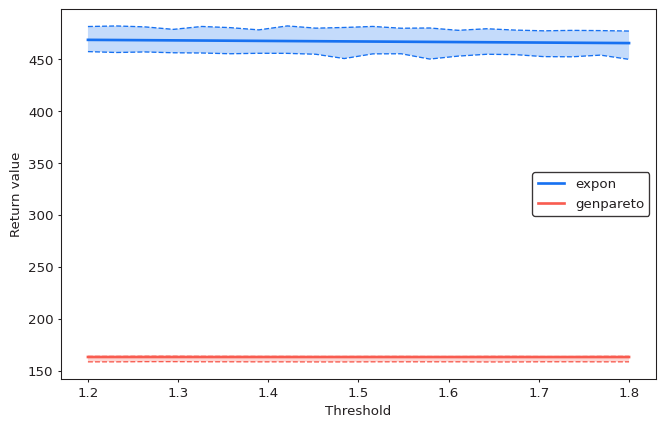

In [ ]:
# GPD è coerente con il valore massimo del nostro dataset, 165 kn.

from pyextremes import plot_return_value_stability

plot_return_value_stability(
    dati,
    return_period=100,
    thresholds=np.linspace(1.2, 1.8, 20),
    alpha=0.95,
)

<Axes: xlabel='Threshold', ylabel='Mean excess'>

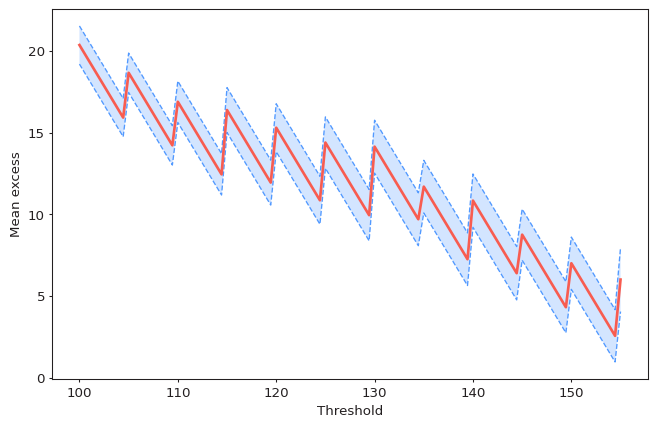

In [ ]:
# L'andamento è decrescente si spiega con lo shape della distribuzione che di segno negativo. Il grafico suggerisce una soglia appartenente al range 110-145 kn, oltre al quale il rumore, in celeste,
# aumenta più ci si avvicina al limite massimo di 165. Osservando il grafico, il giusto compromesso è stato individuato nel dominio dei 110 - 120 nodi.


from pyextremes import plot_mean_residual_life

plot_mean_residual_life(dati)

(<Figure size 768x480 with 1 Axes>, <Axes: xlabel='DATA', ylabel='WMO_WIND'>)

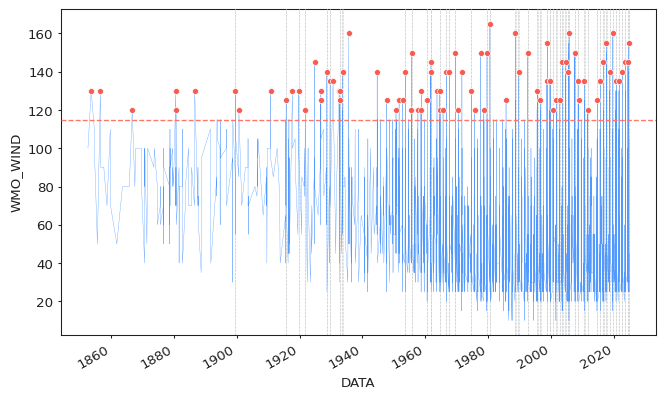

In [ ]:
# Tenuto conto dei grafici precedenti si stabilisce una threshold di 115 kn.

model_POT = EVA(dati)
model_POT.get_extremes(method="POT", threshold = 115, r="30D")
model_POT.plot_extremes(show_clusters=True)


         pyextremes distribution         
-----------------------------------------
name: genpareto                          
free parameters: c, scale                
fixed parameters: floc=115.000           
fitted parameters: c=-0.607, scale=31.052
-----------------------------------------

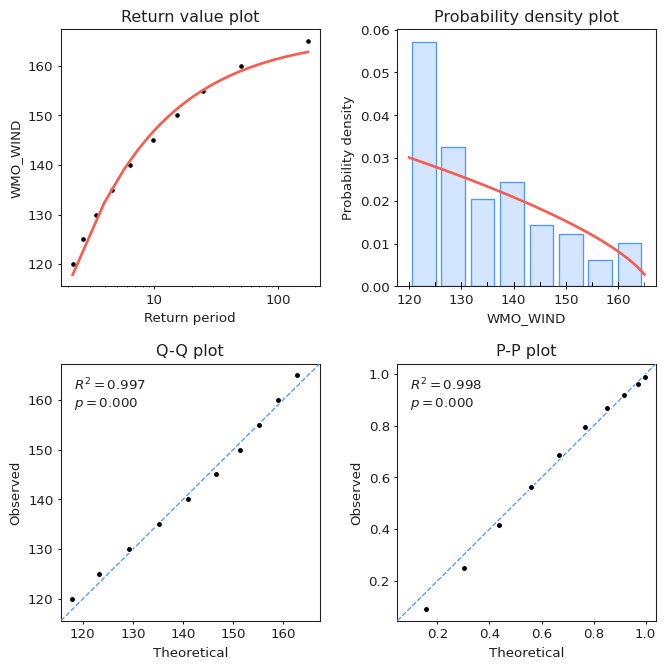

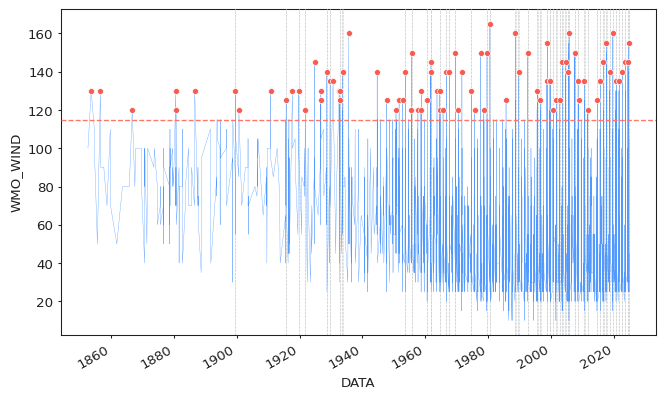

In [ ]:
# In confronto all'approccio Block Maxima si nota un netto miglioramento nel Return value plot con valori estremi verosimili.
# Questi seguono la curva stimata quai perfettamente in un'andamento crescente e lineare.
# Nel Probability density plot, la funzione evidenzia meglio i valori estremi.
# Anche in POT il Q-Q plot illustra una distinta sovrapposizione tra i quantili lievemente divergenti presso le code.
# Similarmente nel P-P plot si nota una dispersione verso i valori minimi. I rispettivi R2, 99.8 e 99.7, sono leggermente inferiori rispetto al modello BM.
# Esso è probabilmente dovuto ad un maggiore numero di picchi massimi utilizzati.

model_POT.fit_model(distribution="genpareto")
model_POT.plot_diagnostic()
model_POT.plot_extremes(show_clusters=True)

# Distribuzione genpareto (GPD)
# parametri: c è ξ (forma) loc è μ (posizione), scale è σ (scala)

model_POT.distribution

In [ ]:
# Valori estremi oltre la soglia

print(len(model_POT.extremes))
model_POT.extremes

87


,WMO_WIND
DATA,
1853-09-03,130.0
1856-08-10,130.0
1866-10-02,120.0
1880-08-13,130.0
1880-10-02,120.0
...,...
2021-09-26,135.0
2022-09-28,140.0
2023-09-08,145.0


In [ ]:
model_POT.extremes.sort_values(ascending=False)

,WMO_WIND
DATA,
1980-08-07,165.0
1935-09-03,160.0
1988-09-14,160.0
2005-10-19,160.0
2019-09-01,160.0
...,...
1970-08-03,120.0
1964-10-01,120.0
1950-09-15,120.0


In [ ]:
# Valori di ritorno con POT

summary2 = model_POT.get_summary(
    return_period=[10, 20, 50, 100],
    alpha=0.95,
    n_samples=1000,
)

In [ ]:
print(summary2)

               return value    lower ci    upper ci
return period                                      
10.0             147.024164  143.251303  153.338433
20.0             153.601844  149.378807  157.388412
50.0             158.967812  154.329069  161.399350
100.0            161.445483  156.784206  163.333475


In [ ]:
#  Calcolo dei periodi di ritorno con il metodo POT

return_periods_pot = get_return_periods(
    ts=dati,
    extremes=model.extremes,      # superamenti sopra soglia
    extremes_method="POT",
    extremes_type="high",
    return_period_size="365.2425D",
)

In [ ]:
# Rispetto a block maxima si nota un lieve abbassamento, di un anno, del periodo di ritorno dell'evento estremo avvenuto  il sette agosto del 1980.

return_periods_pot.sort_values("return period", ascending=False).head()

,WMO_WIND,exceedance probability,return period
DATA,,,
1980-08-07,165.0,0.005747,173.226332
2019-09-01,160.0,0.020115,49.493238
1988-09-14,160.0,0.020115,49.493238
1935-09-03,160.0,0.020115,49.493238
2005-10-19,160.0,0.020115,49.493238
